# Imports

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import ctypes

lib = ctypes.cdll.LoadLibrary('../lib_classification/target/release/lib_classification.dll')

class MyDroite(ctypes.Structure):_fields_ = [
    ("a", ctypes.c_float),
    ("b", ctypes.c_float),
    ("c", ctypes.c_float),
]

lib.initialisation_droite.restype = ctypes.POINTER(MyDroite)
lib.training.restype = ctypes.POINTER(MyDroite)
lib.linear_classification_prediction.restype = ctypes.c_int8
lib.linear_classification_prediction.argtypes = [
        ctypes.c_float,
        ctypes.c_float,
        ctypes.c_float,
        ctypes.c_float,
        ctypes.c_float,
        ctypes.c_float
    ]

# Cas de tests, rendu 2

## Classification

### Linear Simple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [111]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
], dtype=np.float32)
Y = np.array([
      1,
      -1,
      -1
], dtype=np.int8)


ma_droite = lib.initialisation_droite()
a = ma_droite.contents.a
b = ma_droite.contents.b
c = ma_droite.contents.c
w = MyDroite(a, b, c)

In [112]:
data_ptr = X.ctypes.data_as(ctypes.POINTER(ctypes.c_float))


labels_ptr = Y.ctypes.data_as(ctypes.POINTER(ctypes.c_int8))

In [113]:

w = lib.training(ctypes.c_float(0.001), 1000, 3, w, data_ptr, labels_ptr)
w = w.contents

print(w.a)
print(w.b)
print(w.c)


0.503177285194397
0.09429655969142914
-0.269755482673645


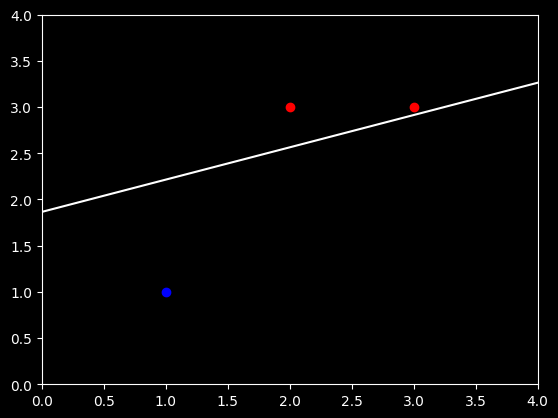

0 1 1
1 -1 -1
2 -1 -1


<Figure size 640x480 with 0 Axes>

In [115]:
x_vals = np.linspace(0, 4, 100)
y_vals = -(w.a + w.b * x_vals) / w.c

plt.scatter(X[0, 0], X[0, 1], color='blue')
plt.scatter(X[1:3,0], X[1:3,1], color='red')
plt.plot(x_vals, y_vals, color='white')
plt.xlim(0, 4)
plt.ylim(0, 4)
plt.show()
plt.clf()

for i in range(len(X)):
    pred = lib.linear_classification_prediction(
        w.a, w.b, w.c,
        1.0, X[i][0], X[i][1]
    )
    print(i, pred, Y[i])

### Linear Multiple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [116]:
X = np.concatenate([np.random.random((50,2)) * 0.9 + np.array([1, 1]), np.random.random((50,2)) * 0.9 + np.array([2, 2])], dtype=np.float32)
Y = np.concatenate([np.ones((50, 1), dtype=np.int8), np.ones((50, 1), dtype=np.int8) * -1.0])

ma_droite1 = lib.initialisation_droite()
a = ma_droite1.contents.a
b = ma_droite1.contents.b
c = ma_droite1.contents.c
w1 = MyDroite(a, b, c)

In [117]:
data_ptr = X.ctypes.data_as(ctypes.POINTER(ctypes.c_float))


labels_ptr = Y.ctypes.data_as(ctypes.POINTER(ctypes.c_int8))

In [182]:
w1 = lib.training(ctypes.c_float(1.0), 100000, 99, w1, data_ptr, labels_ptr)
w1 = w1.contents
print(w1.a, w1.b, w1.c)





4807754.5 9328703.0 9388725.0


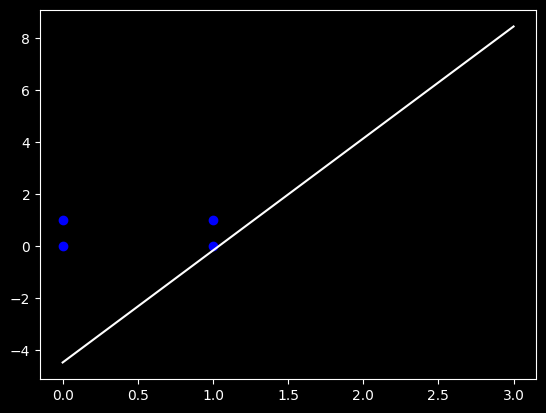

0 -1 1
1 -1 1
2 -1 -1
3 -1 -1


<Figure size 640x480 with 0 Axes>

In [221]:
x_vals = np.linspace(0, 3, 100)
y1_vals = -(w1.a + w1.b * x_vals) / w1.c


plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
plt.scatter(X[50:100,0], X[50:100,1], color='red')
plt.plot(x_vals, y1_vals, color='white')
#plt.xlim(0.9, 3.1)
#plt.ylim(0.9, 3.1)
plt.show()
plt.clf()

for i in range(len(X)):
    pred = lib.linear_classification_prediction(
        w1.a, w1.b, w1.c,
        1.0, X[i][0], X[i][1]
    )
    print(i, pred, Y[i])

### XOR :
        Linear Model    : KO
        MLP (2, 2, 1)   : OK

In [222]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]], dtype=np.float32)
Y = np.array([1, 1, -1, -1], dtype=np.int8)

ma_droite = lib.initialisation_droite()
a = ma_droite.contents.a
b = ma_droite.contents.b
c = ma_droite.contents.c
w = MyDroite(a, b, c)

ma_droite1 = lib.initialisation_droite()
a = ma_droite1.contents.a
b = ma_droite1.contents.b
c = ma_droite1.contents.c
w1 = MyDroite(a, b, c)

In [223]:
data_ptr = X.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

labels_ptr = Y.ctypes.data_as(ctypes.POINTER(ctypes.c_int8))

In [224]:
w = lib.training(ctypes.c_float(0.001), 1000, 4, w, data_ptr, labels_ptr)
w = w.contents

w1 = lib.training(ctypes.c_float(0.001), 1000, 4, w1, data_ptr, labels_ptr)
w1 = w1.contents

print(w.a)
print(w.b)
print(w.c)
print(" ")
print(w1.a)
print(w1.b)
print(w1.c)


-0.006697590462863445
-0.008104253560304642
0.157589852809906
 
0.054881975054740906
-0.05328960344195366
-0.05554107576608658


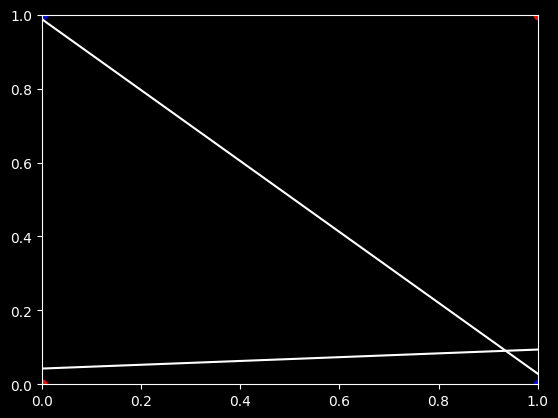

<Figure size 640x480 with 0 Axes>

In [225]:
x_vals = np.linspace(0, 1, 100)
y_vals = -(w.a + w.b * x_vals) / w.c
y1_vals = -(w1.a + w1.b * x_vals) / w1.c

plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.plot(x_vals, y_vals, color='white')
plt.plot(x_vals, y1_vals, color='white')
plt.xlim(-0, 1)
plt.ylim(-0, 1)
plt.show()
plt.clf()

























































































### Cross :
        Linear Model    : KO
        MLP (2, 4, 1)   : OK

In [538]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])

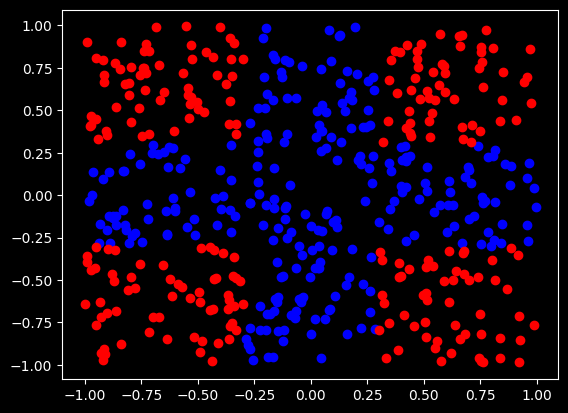

<Figure size 640x480 with 0 Axes>

In [539]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
plt.show()
plt.clf()

### Multi Linear 3 classes :
        Linear Model x3 : OK
        MLP (2, 3)      : OK

In [41]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [-1, -1, -1]for p in X])

X = X[[not np.all(arr == [-1, -1, -1]) for arr in Y]]
Y = Y[[not np.all(arr == [-1, -1, -1]) for arr in Y]]

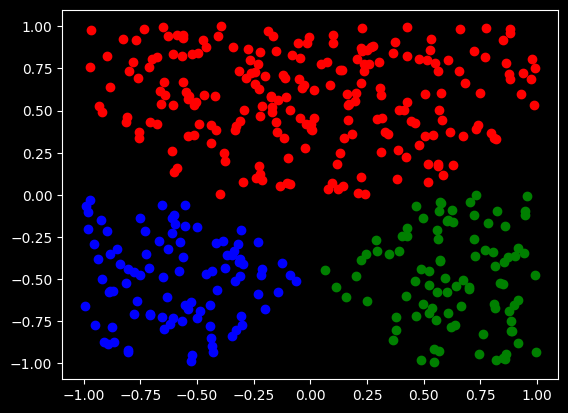

<Figure size 640x480 with 0 Axes>

In [42]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

### Multi Cross :
        Linear Model x3 : KO
        MLP (2, ?, ?, 3): OK

In [43]:
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [-1, -1, 1] for p in X])

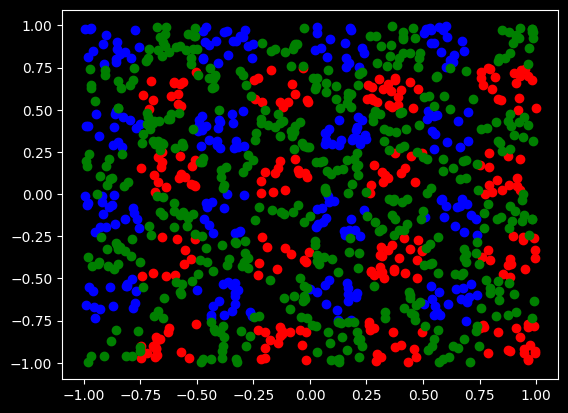

<Figure size 640x480 with 0 Axes>

In [44]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

## Régression

### Linear Simple 2D :
        Linear Model : OK
        MLP (1, 1)   : OK

In [45]:
X = np.array([
      [1],
      [2]
])
Y = np.array([
      2,
      3
])

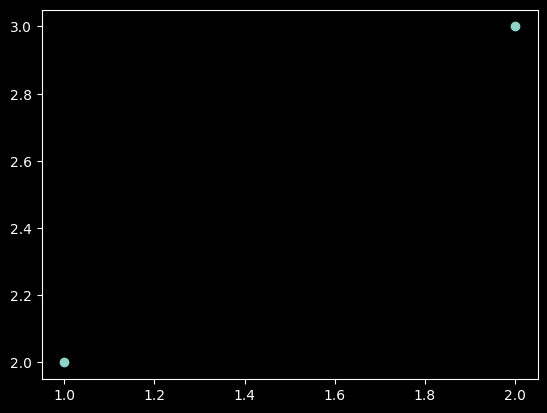

<Figure size 640x480 with 0 Axes>

In [46]:
plt.scatter(X,Y)
plt.show()
plt.clf()

### Non Linear Simple 2D :
        Linear Model    : OK
        MLP (1, ?, 1)   : OK

In [47]:
X = np.array([
      [1],
      [2],
      [3]
])
Y = np.array([
      2,
      3,
      2.5
])

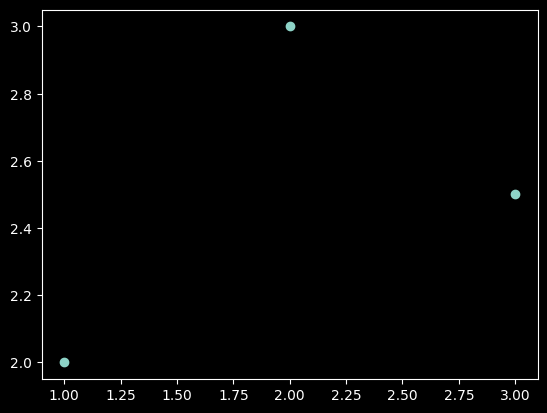

<Figure size 640x480 with 0 Axes>

In [48]:
plt.scatter(X,Y)
plt.show()
plt.clf()

### Linear Simple 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [49]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 1]
])
Y = np.array([
      2,
      3,
      2.5
])

In [50]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

### Linear Tricky 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [51]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 3]
])
Y = np.array([
      1,
      2,
      3
])

In [52]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

### Non Linear Simple 3D :
        Linear Model       : KO
        MLP (2, 2, 1)      : OK

In [53]:
X = np.array([
      [1, 0],
      [0, 1],
      [1, 1],
      [0, 0],
])
Y = np.array([
      2,
      1,
      -2,
      -1
])

In [54]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>